# loading the dataset

In [1]:
import pandas as pd
df=pd.read_csv('DataCoSupplyChainDataset.csv',encoding='ISO-8859-1')

In [2]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [3]:
# Display the first few rows to verify the data load
print("=== First 5 Rows of Supply Chain Dataset ===")
print(df.head())

=== First 5 Rows of Supply Chain Dataset ===
       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                   0           73  Sporting Goods        Caguas  ...   
1  

In [4]:
#checking the  types of the data

In [5]:
# Check and print data types for each column
print("\n=== Data Types ===")
print(df.dtypes)


=== Data Types ===
Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        floa

# missing values finding

In [6]:
print("\n=== Missing Values Count ===")
missing_values = df.isnull().sum()
print(missing_values)


=== Missing Values Count ===
Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market    

In [7]:
def features_with_missing_values(data):
    x = data.isnull().sum().sum()/(data.shape[0]*data.shape[1])*100
    print('Percentage of Total Missing Values is ' ,round(x,2) ,'%')
    print('Missing Value Estimation :')
    for i in data.columns:
        if data[i].isna().sum()>0:
            print('The Feature ',i,' has '+ str(data[i].isna().sum()) + ' missing values')
            
features_with_missing_values(df)

Percentage of Total Missing Values is  3.51 %
Missing Value Estimation :
The Feature  Customer Lname  has 8 missing values
The Feature  Customer Zipcode  has 3 missing values
The Feature  Order Zipcode  has 155679 missing values
The Feature  Product Description  has 180519 missing values


# description of the dataset

In [8]:
print("\n=== Descriptive Statistics (Categorical Columns) ===")
print(df.describe(include=['O']))


=== Descriptive Statistics (Categorical Columns) ===
          Type Delivery Status Category Name Customer City Customer Country  \
count   180519          180519        180519        180519           180519   
unique       4               4            50           563                2   
top      DEBIT   Late delivery        Cleats        Caguas          EE. UU.   
freq     69295           98977         24551         66770           111146   

       Customer Email Customer Fname Customer Lname Customer Password  \
count          180519         180519         180511            180519   
unique              1            782           1109                 1   
top         XXXXXXXXX           Mary          Smith         XXXXXXXXX   
freq           180519          65150          64104            180519   

       Customer Segment  ...     Order City   Order Country  \
count            180519  ...         180519          180519   
unique                3  ...           3597             16

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

# Size of the dataset

In [10]:
print(f"Dataset rows: {df.shape[0]}")
print(f"Dataset columns: {df.shape[1]}")

Dataset rows: 180519
Dataset columns: 53


# unique values

In [11]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
   unique_values = df[col].unique()
   num_unique = len(unique_values)
   print(f"\nColumn: {col}")
   print(f"Number of unique values: {num_unique}")
   #print("Unique values:")
   #print(unique_values)


Column: Type
Number of unique values: 4

Column: Delivery Status
Number of unique values: 4

Column: Category Name
Number of unique values: 50

Column: Customer City
Number of unique values: 563

Column: Customer Country
Number of unique values: 2

Column: Customer Email
Number of unique values: 1

Column: Customer Fname
Number of unique values: 782

Column: Customer Lname
Number of unique values: 1110

Column: Customer Password
Number of unique values: 1

Column: Customer Segment
Number of unique values: 3

Column: Customer State
Number of unique values: 46

Column: Customer Street
Number of unique values: 7458

Column: Department Name
Number of unique values: 11

Column: Market
Number of unique values: 5

Column: Order City
Number of unique values: 3597

Column: Order Country
Number of unique values: 164

Column: order date (DateOrders)
Number of unique values: 65752

Column: Order Region
Number of unique values: 23

Column: Order State
Number of unique values: 1089

Column: Order S

# preprocessing

In [13]:
modeling_columns = ['Type',
                  'Days for shipping (real)', 
                  'Days for shipment (scheduled)',
                  'Benefit per order',
                  'Sales per customer',
                  'Late_delivery_risk', 
                  'order date (DateOrders)',
                  'Order Item Discount',
                  'Order Item Discount Rate', 
                  'Order Item Product Price',
                  'Order Item Profit Ratio',
                  'Order Item Quantity', 
                  'Sales',                    
                  'Order Item Total',
                  'Order Profit Per Order',
                  'Product Price',
                  'shipping date (DateOrders)',
                  'Shipping Mode']

In [14]:
len(modeling_columns)

18

In [15]:
def drop_columns(dataset, columns_to_drop):
    dataset = dataset.drop(columns=columns_to_drop)
    print(f"{len(columns_to_drop)} columns dropped successfully. Number of columns remaining: {len(dataset.columns)}")
    return dataset

In [16]:
columns_to_drop = [col for col in df.columns if col not in modeling_columns]

In [17]:
len(columns_to_drop)

35

In [18]:
df1=drop_columns(df,columns_to_drop)

35 columns dropped successfully. Number of columns remaining: 18


In [19]:
print(f"Dataset rows: {df1.shape[0]}")
print(f"Dataset columns: {df1.shape[1]}")

Dataset rows: 180519
Dataset columns: 18


In [20]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,0,1/31/2018 22:56,13.110000,0.04,327.750000,0.29,1,327.750000,314.640015,91.250000,327.750000,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,1,1/13/2018 12:27,16.389999,0.05,327.750000,-0.80,1,327.750000,311.359985,-249.089996,327.750000,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,0,1/13/2018 12:06,18.030001,0.06,327.750000,-0.80,1,327.750000,309.720001,-247.779999,327.750000,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,0,1/13/2018 11:45,22.940001,0.07,327.750000,0.08,1,327.750000,304.809998,22.860001,327.750000,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,0,1/13/2018 11:24,29.500000,0.09,327.750000,0.45,1,327.750000,298.250000,134.210007,327.750000,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,0,1/16/2016 3:40,0.000000,0.00,399.980011,0.10,1,399.980011,399.980011,40.000000,399.980011,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,1,1/16/2016 1:34,4.000000,0.01,399.980011,-1.55,1,399.980011,395.980011,-613.770019,399.980011,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,1,1/15/2016 21:00,8.000000,0.02,399.980011,0.36,1,399.980011,391.980011,141.110001,399.980011,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,0,1/15/2016 20:18,12.000000,0.03,399.980011,0.48,1,399.980011,387.980011,186.229996,399.980011,1/18/2016 20:18,Standard Class


In [21]:
df1.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'order date (DateOrders)', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Product Price',
       'shipping date (DateOrders)', 'Shipping Mode'],
      dtype='object')

In [21]:
# check null values
df1.isna().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Late_delivery_risk               0
order date (DateOrders)          0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product Price         0
Order Item Profit Ratio          0
Order Item Quantity              0
Sales                            0
Order Item Total                 0
Order Profit Per Order           0
Product Price                    0
shipping date (DateOrders)       0
Shipping Mode                    0
dtype: int64

In [22]:
#analyze categorical columns 
categorical_cols = df1.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
   unique_values = df1[col].unique()
   num_unique = len(unique_values)
   print(f"\nColumn: {col}")
   print(f"Number of unique values: {num_unique}")
   #print("Unique values:")
   #print(unique_values)


Column: Type
Number of unique values: 4

Column: order date (DateOrders)
Number of unique values: 65752

Column: shipping date (DateOrders)
Number of unique values: 63701

Column: Shipping Mode
Number of unique values: 4


In [23]:
df1['order date (DateOrders)'] = pd.to_datetime(df1['order date (DateOrders)'])
df1['shipping date (DateOrders)'] = pd.to_datetime(df1['shipping date (DateOrders)'])

# Create new features:
df1['order_day'] = df1['order date (DateOrders)'].dt.day
df1['order_month'] = df1['order date (DateOrders)'].dt.month
df1['order_year'] = df1['order date (DateOrders)'].dt.year

df1['shipping_duration'] = (df1['shipping date (DateOrders)'] - df1['order date (DateOrders)']).dt.days


In [24]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Discount,Order Item Discount Rate,Order Item Product Price,...,Sales,Order Item Total,Order Profit Per Order,Product Price,shipping date (DateOrders),Shipping Mode,order_day,order_month,order_year,shipping_duration
0,DEBIT,3,4,91.250000,314.640015,0,2018-01-31 22:56:00,13.110000,0.04,327.750000,...,327.750000,314.640015,91.250000,327.750000,2018-02-03 22:56:00,Standard Class,31,1,2018,3
1,TRANSFER,5,4,-249.089996,311.359985,1,2018-01-13 12:27:00,16.389999,0.05,327.750000,...,327.750000,311.359985,-249.089996,327.750000,2018-01-18 12:27:00,Standard Class,13,1,2018,5
2,CASH,4,4,-247.779999,309.720001,0,2018-01-13 12:06:00,18.030001,0.06,327.750000,...,327.750000,309.720001,-247.779999,327.750000,2018-01-17 12:06:00,Standard Class,13,1,2018,4
3,DEBIT,3,4,22.860001,304.809998,0,2018-01-13 11:45:00,22.940001,0.07,327.750000,...,327.750000,304.809998,22.860001,327.750000,2018-01-16 11:45:00,Standard Class,13,1,2018,3
4,PAYMENT,2,4,134.210007,298.250000,0,2018-01-13 11:24:00,29.500000,0.09,327.750000,...,327.750000,298.250000,134.210007,327.750000,2018-01-15 11:24:00,Standard Class,13,1,2018,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,0,2016-01-16 03:40:00,0.000000,0.00,399.980011,...,399.980011,399.980011,40.000000,399.980011,2016-01-20 03:40:00,Standard Class,16,1,2016,4
180515,DEBIT,3,2,-613.770019,395.980011,1,2016-01-16 01:34:00,4.000000,0.01,399.980011,...,399.980011,395.980011,-613.770019,399.980011,2016-01-19 01:34:00,Second Class,16,1,2016,3
180516,TRANSFER,5,4,141.110001,391.980011,1,2016-01-15 21:00:00,8.000000,0.02,399.980011,...,399.980011,391.980011,141.110001,399.980011,2016-01-20 21:00:00,Standard Class,15,1,2016,5
180517,PAYMENT,3,4,186.229996,387.980011,0,2016-01-15 20:18:00,12.000000,0.03,399.980011,...,399.980011,387.980011,186.229996,399.980011,2016-01-18 20:18:00,Standard Class,15,1,2016,3


In [25]:
#analyze categorical columns 
categorical_cols = df1.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
   unique_values = df1[col].unique()
   num_unique = len(unique_values)
   print(f"\nColumn: {col}")
   print(f"Number of unique values: {num_unique}")
   #print("Unique values:")
   #print(unique_values)


Column: Type
Number of unique values: 4

Column: Shipping Mode
Number of unique values: 4


# count the number of duplicate rows

In [26]:
df1.duplicated().sum()

0

In [27]:
#df1 = df1.fillna(0) for handling missing values

In [28]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Discount,Order Item Discount Rate,Order Item Product Price,...,Sales,Order Item Total,Order Profit Per Order,Product Price,shipping date (DateOrders),Shipping Mode,order_day,order_month,order_year,shipping_duration
0,DEBIT,3,4,91.250000,314.640015,0,2018-01-31 22:56:00,13.110000,0.04,327.750000,...,327.750000,314.640015,91.250000,327.750000,2018-02-03 22:56:00,Standard Class,31,1,2018,3
1,TRANSFER,5,4,-249.089996,311.359985,1,2018-01-13 12:27:00,16.389999,0.05,327.750000,...,327.750000,311.359985,-249.089996,327.750000,2018-01-18 12:27:00,Standard Class,13,1,2018,5
2,CASH,4,4,-247.779999,309.720001,0,2018-01-13 12:06:00,18.030001,0.06,327.750000,...,327.750000,309.720001,-247.779999,327.750000,2018-01-17 12:06:00,Standard Class,13,1,2018,4
3,DEBIT,3,4,22.860001,304.809998,0,2018-01-13 11:45:00,22.940001,0.07,327.750000,...,327.750000,304.809998,22.860001,327.750000,2018-01-16 11:45:00,Standard Class,13,1,2018,3
4,PAYMENT,2,4,134.210007,298.250000,0,2018-01-13 11:24:00,29.500000,0.09,327.750000,...,327.750000,298.250000,134.210007,327.750000,2018-01-15 11:24:00,Standard Class,13,1,2018,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,0,2016-01-16 03:40:00,0.000000,0.00,399.980011,...,399.980011,399.980011,40.000000,399.980011,2016-01-20 03:40:00,Standard Class,16,1,2016,4
180515,DEBIT,3,2,-613.770019,395.980011,1,2016-01-16 01:34:00,4.000000,0.01,399.980011,...,399.980011,395.980011,-613.770019,399.980011,2016-01-19 01:34:00,Second Class,16,1,2016,3
180516,TRANSFER,5,4,141.110001,391.980011,1,2016-01-15 21:00:00,8.000000,0.02,399.980011,...,399.980011,391.980011,141.110001,399.980011,2016-01-20 21:00:00,Standard Class,15,1,2016,5
180517,PAYMENT,3,4,186.229996,387.980011,0,2016-01-15 20:18:00,12.000000,0.03,399.980011,...,399.980011,387.980011,186.229996,399.980011,2016-01-18 20:18:00,Standard Class,15,1,2016,3


In [29]:
df1.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'order date (DateOrders)', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Product Price',
       'shipping date (DateOrders)', 'Shipping Mode', 'order_day',
       'order_month', 'order_year', 'shipping_duration'],
      dtype='object')

In [30]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Type', 'Shipping Mode']
le = LabelEncoder()
for col in categorical_cols:
    df1[col] = le.fit_transform(df1[col])

In [31]:
df1.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Discount,Order Item Discount Rate,Order Item Product Price,...,Sales,Order Item Total,Order Profit Per Order,Product Price,shipping date (DateOrders),Shipping Mode,order_day,order_month,order_year,shipping_duration
0,1,3,4,91.250000,314.640015,0,2018-01-31 22:56:00,13.110000,0.04,327.75,...,327.75,314.640015,91.250000,327.75,2018-02-03 22:56:00,3,31,1,2018,3
1,3,5,4,-249.089996,311.359985,1,2018-01-13 12:27:00,16.389999,0.05,327.75,...,327.75,311.359985,-249.089996,327.75,2018-01-18 12:27:00,3,13,1,2018,5
2,0,4,4,-247.779999,309.720001,0,2018-01-13 12:06:00,18.030001,0.06,327.75,...,327.75,309.720001,-247.779999,327.75,2018-01-17 12:06:00,3,13,1,2018,4
3,1,3,4,22.860001,304.809998,0,2018-01-13 11:45:00,22.940001,0.07,327.75,...,327.75,304.809998,22.860001,327.75,2018-01-16 11:45:00,3,13,1,2018,3
4,2,2,4,134.210007,298.250000,0,2018-01-13 11:24:00,29.500000,0.09,327.75,...,327.75,298.250000,134.210007,327.75,2018-01-15 11:24:00,3,13,1,2018,2


In [32]:
df1 = df1.drop(columns=['order date (DateOrders)', 'shipping date (DateOrders)'])

In [33]:
df1.shape

(180519, 20)

# Separate Features and Target

In [34]:
X = df1.drop(columns=['Late_delivery_risk'])  # features
y = df1['Late_delivery_risk']                 # target

In [35]:
X

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price,Shipping Mode,order_day,order_month,order_year,shipping_duration
0,1,3,4,91.250000,314.640015,13.110000,0.04,327.750000,0.29,1,327.750000,314.640015,91.250000,327.750000,3,31,1,2018,3
1,3,5,4,-249.089996,311.359985,16.389999,0.05,327.750000,-0.80,1,327.750000,311.359985,-249.089996,327.750000,3,13,1,2018,5
2,0,4,4,-247.779999,309.720001,18.030001,0.06,327.750000,-0.80,1,327.750000,309.720001,-247.779999,327.750000,3,13,1,2018,4
3,1,3,4,22.860001,304.809998,22.940001,0.07,327.750000,0.08,1,327.750000,304.809998,22.860001,327.750000,3,13,1,2018,3
4,2,2,4,134.210007,298.250000,29.500000,0.09,327.750000,0.45,1,327.750000,298.250000,134.210007,327.750000,3,13,1,2018,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,0,4,4,40.000000,399.980011,0.000000,0.00,399.980011,0.10,1,399.980011,399.980011,40.000000,399.980011,3,16,1,2016,4
180515,1,3,2,-613.770019,395.980011,4.000000,0.01,399.980011,-1.55,1,399.980011,395.980011,-613.770019,399.980011,2,16,1,2016,3
180516,3,5,4,141.110001,391.980011,8.000000,0.02,399.980011,0.36,1,399.980011,391.980011,141.110001,399.980011,3,15,1,2016,5
180517,2,3,4,186.229996,387.980011,12.000000,0.03,399.980011,0.48,1,399.980011,387.980011,186.229996,399.980011,3,15,1,2016,3


In [36]:
y

0         0
1         1
2         0
3         0
4         0
         ..
180514    0
180515    1
180516    1
180517    0
180518    0
Name: Late_delivery_risk, Length: 180519, dtype: int64

# Normalize Feature Values

In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
X_scaled

array([[0.33333333, 0.5       , 1.        , ..., 0.        , 1.        ,
        0.5       ],
       [1.        , 0.83333333, 1.        , ..., 0.        , 1.        ,
        0.83333333],
       [0.        , 0.66666667, 1.        , ..., 0.        , 1.        ,
        0.66666667],
       ...,
       [1.        , 0.83333333, 1.        , ..., 0.        , 0.33333333,
        0.83333333],
       [0.66666667, 0.5       , 1.        , ..., 0.        , 0.33333333,
        0.5       ],
       [0.66666667, 0.66666667, 1.        , ..., 0.        , 0.33333333,
        0.66666667]])

In [39]:
X_scaled.shape

(180519, 19)

# converting into 3D shape because for LSTM we need to convert the data

In [40]:
import numpy as np
X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

In [41]:
X_lstm.shape   #(samples, time steps, features)

(180519, 1, 19)

In [42]:
X.shape[1]

19

In [43]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Input

# Define LSTM Model
input_layer = Input(shape=(1, X.shape[1]))
lstm_layer = LSTM(64, return_sequences=False)(input_layer)  # Output: (batch_size, 64) hidden size of the LSTM layer.
model = Model(inputs=input_layer, outputs=lstm_layer)

In [44]:
model

In [45]:
X_features = model.predict(X_lstm)
print(X_features.shape)  # (num_samples, 64)

5642/5642 [==============================] - 13s 2ms/step
(180519, 64)


In [46]:
y.shape

(180519,)

In [ ]:
#np.save("simple_LSTM_softmax_rf_64_64",X_features)

In [ ]:
#np.load('simple_LSTM_softmax_rf_64_64.npy')

In [47]:
set(y)

{0, 1}

# softmax

In [48]:
from tensorflow.keras.utils import to_categorical

y_categorical = to_categorical(y)  # This converts [0,1,0,...] to [[1,0],[0,1],...]

In [49]:
y_categorical[0] ,y_categorical.shape

(array([1., 0.], dtype=float32), (180519, 2))

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_features, y_categorical, test_size=0.2, random_state=42)

In [51]:
X_train.shape, X_test.shape , y_train.shape , y_test.shape

((144415, 64), (36104, 64), (144415, 2), (36104, 2))

In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_softmax = Sequential()
model_softmax.add(Dense(64, input_shape=(64,), activation='relu'))  # You can tune this
model_softmax.add(Dropout(0.3))
model_softmax.add(Dense(y_categorical.shape[1], activation='softmax'))  # Output layer

In [56]:
model_softmax.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model_softmax.fit(X_train, y_train, epochs=20, batch_size=128, validation_split=0.2)

Epoch 1/20
903/903 [==============================] - 3s 3ms/step - loss: 0.0708 - accuracy: 0.9758 - val_loss: 0.0709 - val_accuracy: 0.9749
Epoch 2/20
903/903 [==============================] - 2s 2ms/step - loss: 0.0704 - accuracy: 0.9757 - val_loss: 0.0707 - val_accuracy: 0.9749
Epoch 3/20
903/903 [==============================] - 2s 3ms/step - loss: 0.0699 - accuracy: 0.9757 - val_loss: 0.0708 - val_accuracy: 0.9749
Epoch 4/20
903/903 [==============================] - 2s 2ms/step - loss: 0.0694 - accuracy: 0.9757 - val_loss: 0.0701 - val_accuracy: 0.9749
Epoch 5/20
903/903 [==============================] - 2s 3ms/step - loss: 0.0694 - accuracy: 0.9757 - val_loss: 0.0702 - val_accuracy: 0.9749
Epoch 6/20
903/903 [==============================] - 2s 2ms/step - loss: 0.0694 - accuracy: 0.9757 - val_loss: 0.0702 - val_accuracy: 0.9749
Epoch 7/20
903/903 [==============================] - 3s 3ms/step - loss: 0.0691 - accuracy: 0.9757 - val_loss: 0.0700 - val_accuracy: 0.9749
Epoch 

In [57]:
loss, accuracy = model_softmax.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

1129/1129 [==============================] - 2s 1ms/step - loss: 0.0698 - accuracy: 0.9749
Test Accuracy: 97.49%


In [58]:
training_accuracy = history.history['accuracy'][-1]  # Accuracy from the last epoch
print(f"Training Accuracy: {training_accuracy * 100:.2f}%")

Training Accuracy: 97.58%


In [66]:
num_classes = len(np.unique(y))  # ✅ number of unique class labels
num_classes

2

In [67]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(X_features.shape[1],)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # use your number of classes
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
accuracy_list=[]

In [68]:
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf

for train_index, test_index in kf.split(X):
    X_tr, X_te = X[train_index], X[test_index]
    y_tr, y_te = y[train_index], y[test_index]
    
    model = build_model()  # ✅ fresh model each fold
    
    model.fit(X_tr, y_tr, epochs=20, batch_size=128, verbose=0, validation_split=0.2)
    
    y_pred_prob = model.predict(X_te)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    accuracy = accuracy_score(y_te, y_pred)
    accuracy_list.append(accuracy)


1129/1129 [==============================] - 1s 795us/step


In [69]:
accuracy_list

[0.9748504320850875,
 0.9757921559937957,
 0.9764292045202747,
 0.9756813649457123,
 0.9747389413622136]

In [131]:
import numpy as np

predictions = model_softmax.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

# Decode back to original labels
final_predictions = label_encoder.inverse_transform(predicted_labels)

In [142]:
from sklearn.metrics import classification_report, confusion_matrix

# Convert y_test from one-hot to integer labels
y_test_labels = np.argmax(y_test, axis=1)

# If you want original labels (like 0 or 1), you can decode them
y_test_decoded = label_encoder.inverse_transform(y_test_labels)
final_predictions_decoded = label_encoder.inverse_transform(predicted_labels)

# Now compare
print("Classification Report:\n")
print(classification_report(y_test_decoded, final_predictions_decoded))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     16307
           1       0.96      1.00      0.98     19797

    accuracy                           0.97     36104
   macro avg       0.98      0.97      0.97     36104
weighted avg       0.98      0.97      0.97     36104



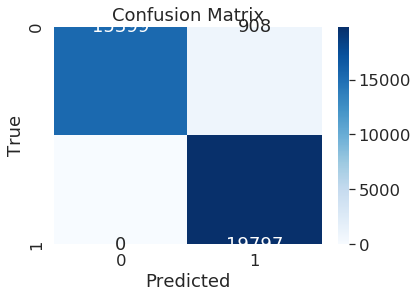

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test_labels, predicted_labels)

#plt.figure(figsize=(8,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

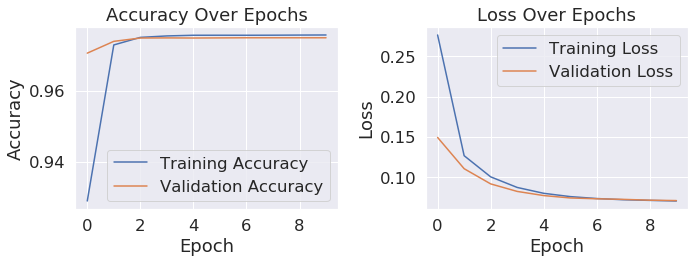

In [172]:
# Accuracy Plot
plt.figure(figsize=(10, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history.get('val_accuracy', []), label='Validation Accuracy')  # if used
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history.get('val_loss', []), label='Validation Loss')  # if used
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


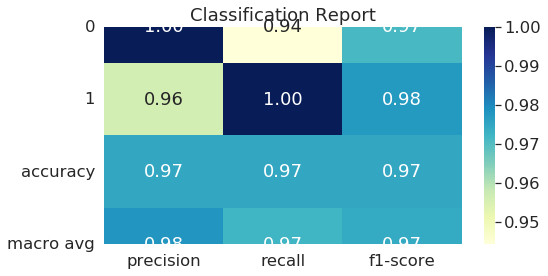

In [173]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test_labels, predicted_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

# Random forest

In [175]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2, random_state=42)

In [187]:
X_train.shape, X_test.shape , y_train.shape , y_test.shape

((144415, 64), (36104, 64), (144415,), (36104,))

In [202]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
history=rf.fit(X_train, y_train)  # features_train from LSTM on training set

# Predict on test features
y_pred = rf.predict(X_test)

In [203]:
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9732162641258586
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     16307
           1       0.96      1.00      0.98     19797

    accuracy                           0.97     36104
   macro avg       0.98      0.97      0.97     36104
weighted avg       0.97      0.97      0.97     36104



In [200]:
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 97.49%


In [199]:
y_train_pred = rf.predict(X_train)

# Calculate training accuracy
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_acc * 100:.2f}%")

Training Accuracy: 100.00%
